In [70]:
!pip install pytrends==4.7.2 pandas matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for pytrends: filename=pytrends-4.7.2-py3-none-any.whl size=14259 sha256=4534609cd97a98691043260b775355b3ceaf1150227fc82ed99dc9b987d3ec7d
  Stored in directory: /home/yunho/.cache/pip/wheels/ac/cf/41/068c2204e983f8644eebf872be585ab76c507054f87578ca37
Successfully built pytrends
  Attempting uninstall: pytrends
    Found existing installation: pytrends 4.8.0
    Uninstalling pytrends-4.8.0:
      Successfully uninstalled pytrends-4.8.0


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from pytrends.request import TrendReq

import datetime
import time
pytrends = TrendReq(hl='ko', tz=540)  # 한국어, 한국 시간대(UTC+9)


=== Interest Over Time 테스트 ===
결과 데이터 형태: (90, 2)
컬럼: Index(['AI', 'isPartial'], dtype='object')

샘플 데이터 (처음 5행):
            AI  isPartial
date                     
2025-02-12  69      False
2025-02-13  65      False
2025-02-14  66      False
2025-02-15  52      False
2025-02-16  54      False


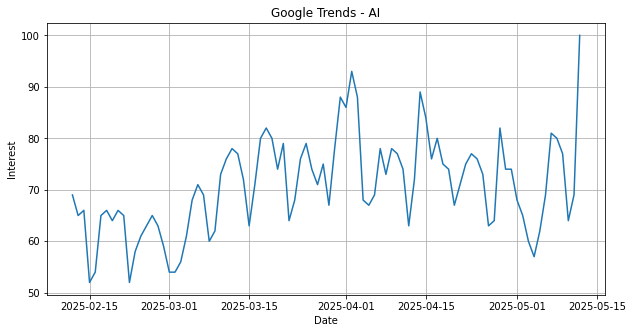

In [57]:
print("=== Interest Over Time 테스트 ===")
try:
    # 관심 키워드 설정
    kw_list = ["AI"]
    pytrends.build_payload(kw_list, cat=0, timeframe='today 3-m', geo='KR', gprop='')
    # 결과 가져오기
    interest_over_time_df = pytrends.interest_over_time()
    
    print(f"결과 데이터 형태: {interest_over_time_df.shape}")
    print(f"컬럼: {interest_over_time_df.columns}")
    print("\n샘플 데이터 (처음 5행):")
    print(interest_over_time_df.head())
    
    # 그래프로 확인
    plt.figure(figsize=(10, 5))
    plt.plot(interest_over_time_df.index, interest_over_time_df[kw_list[0]])
    plt.title(f'Google Trends - {kw_list[0]}')
    plt.xlabel('Date')
    plt.ylabel('Interest')
    plt.grid(True)
    plt.show()
    
except Exception as e:
    print(f"오류 발생: {str(e)}")

# API 요청 사이 간격을 두기 위해 대기
time.sleep(60)

In [75]:
keywords = pytrends.suggestions(keyword='AI')
df = pd.DataFrame(keywords)
df.drop(columns= 'mid')

,title,type
0,Character AI,앱
1,Perplexity.ai,회사
2,오픈AI,기업
3,Airalo,주제
4,Grok,앱


In [78]:
trending_searches_df = pytrends.trending_searches(pn='south_korea')      
print(trending_searches_df.head(10))      

ResponseError: The request failed: Google returned a response with code 404